# Gasoline Price Pass-Through — Step 2: Data Cleaning & Merging

This notebook:
1. Loads all raw data from Step 1
2. Cleans each dataset (nulls, negatives, types)
3. Aligns everything to weekly frequency
4. Merges into one master dataset
5. Generates presentation-ready summaries and visuals

**Run this after `01_Data_Collection.ipynb` has completed successfully.**

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

Path('data/processed').mkdir(parents=True, exist_ok=True)
Path('outputs').mkdir(parents=True, exist_ok=True)

print('✅ Setup complete')

✅ Setup complete


---
## 1. Load Raw Data

Load everything we collected in Step 1.

In [2]:
# ---- EIA Data ----
retail_gas   = pd.read_csv('data/raw/eia/retail_gasoline_prices.csv', parse_dates=['period'])
spot_prices  = pd.read_csv('data/raw/eia/spot_prices.csv', parse_dates=['period'])
refinery_util = pd.read_csv('data/raw/eia/refinery_utilization.csv', parse_dates=['period'])
gas_stocks   = pd.read_csv('data/raw/eia/gasoline_stocks.csv', parse_dates=['period'])
futures      = pd.read_csv('data/raw/eia/futures_prices.csv', parse_dates=['period'])

# ---- FRED Data ----
fred_files = {
    'DCOILWTICO':  'WTI Crude Oil',
    'DCOILBRENTEU': 'Brent Crude Oil',
    'DTWEXBGS':    'USD Index',
    'CPIAUCSL':    'CPI',
    'UMCSENT':     'Consumer Sentiment',
    'DFF':         'Fed Funds Rate',
    'GASREGW':     'Gas Price (FRED)',
}

fred_data = {}
for series_id, label in fred_files.items():
    path = f'data/raw/fred/{series_id}.csv'
    if Path(path).exists():
        fred_data[series_id] = pd.read_csv(path, parse_dates=['date'])
    else:
        print(f'  ⚠️ Missing: {path}')

print(f'✅ Loaded {5} EIA datasets and {len(fred_data)} FRED series')

✅ Loaded 5 EIA datasets and 7 FRED series


---
## 2. Explore Raw Structure

Before cleaning, let's understand what each dataset looks like — column names, data types, sample values.

In [3]:
raw_datasets = {
    'Retail Gasoline': retail_gas,
    'Spot Prices': spot_prices,
    'Refinery Utilization': refinery_util,
    'Gasoline Stocks': gas_stocks,
    'Futures': futures,
}

for name, df in raw_datasets.items():
    print(f'\n{"=" * 60}')
    print(f'{name}: {df.shape[0]} rows × {df.shape[1]} columns')
    print(f'{"=" * 60}')
    print(f'Columns: {df.columns.tolist()}')
    print(f'\nDate range: {df["period"].min()} → {df["period"].max()}')
    if 'value' in df.columns:
        print(f'Value: min={df["value"].min():.2f}, max={df["value"].max():.2f}, nulls={df["value"].isna().sum()}')
    # Show unique identifiers (series, duoarea, product, etc.)
    for col in ['duoarea', 'series', 'series-description', 'product', 'product-name', 'process', 'process-name']:
        if col in df.columns:
            print(f'{col}: {df[col].unique().tolist()[:10]}')
    display(df.head(3))


Retail Gasoline: 10332 rows × 11 columns
Columns: ['period', 'duoarea', 'area-name', 'product', 'product-name', 'process', 'process-name', 'series', 'series-description', 'value', 'units']

Date range: 1993-04-05 00:00:00 → 2026-03-30 00:00:00
Value: min=0.89, max=5.98, nulls=0
duoarea: ['NUS', 'R50', 'R40', 'R30', 'R20', 'R10']
series: ['EMM_EPM0_PTE_NUS_DPG', 'EMM_EPM0_PTE_R50_DPG', 'EMM_EPM0_PTE_R40_DPG', 'EMM_EPM0_PTE_R30_DPG', 'EMM_EPM0_PTE_R20_DPG', 'EMM_EPM0_PTE_R10_DPG']
series-description: ['U.S. All Grades All Formulations Retail Gasoline Prices (Dollars per Gallon)', 'West Coast All Grades All Formulations Retail Gasoline Prices (Dollars per Gallon)', 'Rocky Mountain All Grades All Formulations Retail Gasoline Prices (Dollars per Gallon)', 'Gulf Coast All Grades All Formulations Retail Gasoline Prices (Dollars per Gallon)', 'Midwest All Grades All Formulations Retail Gasoline Prices (Dollars per Gallon)', 'East Coast All Grades All Formulations Retail Gasoline Prices (Dolla

,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,1993-04-05,NUS,U.S.,EPM0,Total Gasoline,PTE,Retail Sales,EMM_EPM0_PTE_NUS_DPG,U.S. All Grades All Formulations Retail Gasoli...,1.068,$/GAL
1,1993-04-05,R50,PADD 5,EPM0,Total Gasoline,PTE,Retail Sales,EMM_EPM0_PTE_R50_DPG,West Coast All Grades All Formulations Retail ...,1.152,$/GAL
2,1993-04-05,R40,PADD 4,EPM0,Total Gasoline,PTE,Retail Sales,EMM_EPM0_PTE_R40_DPG,Rocky Mountain All Grades All Formulations Ret...,1.093,$/GAL



Spot Prices: 6256 rows × 11 columns
Columns: ['period', 'duoarea', 'area-name', 'product', 'product-name', 'process', 'process-name', 'series', 'series-description', 'value', 'units']

Date range: 1986-01-03 00:00:00 → 2026-03-27 00:00:00
Value: min=0.28, max=142.52, nulls=0
duoarea: ['YCUOK', 'RGC', 'Y35NY']
series: ['RWTC', 'EER_EPMRU_PF4_RGC_DPG', 'EER_EPMRU_PF4_Y35NY_DPG']
series-description: ['Cushing, OK WTI Spot Price FOB (Dollars per Barrel)', 'U.S. Gulf Coast Conventional Gasoline Regular Spot Price FOB (Dollars per Gallon)', 'New York Harbor Conventional Gasoline Regular Spot Price FOB (Dollars per Gallon)']
product: ['EPCWTI', 'EPMRU']
product-name: ['WTI Crude Oil', 'Conventional Regular Gasoline']
process: ['PF4']
process-name: ['Spot Price FOB']


,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,1986-01-03,YCUOK,NaN,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",25.78,$/BBL
1,1986-01-10,YCUOK,NaN,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",25.99,$/BBL
2,1986-01-17,YCUOK,NaN,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",24.57,$/BBL



Refinery Utilization: 71810 rows × 11 columns
Columns: ['period', 'duoarea', 'area-name', 'product', 'product-name', 'process', 'process-name', 'series', 'series-description', 'value', 'units']

Date range: 1982-08-20 00:00:00 → 2026-03-27 00:00:00
Value: min=-2844.00, max=18976.00, nulls=7370
duoarea: ['NUS', 'R50', 'R40', 'R30', 'R20', 'R10']
series: ['WCRRIUS2', 'WOCLEUS2', 'WGIRIUS2', 'WGIRIP52', 'WGIRIP42', 'WGIRIP32', 'WGIRIP22', 'WGIRIP12', 'WPULEUS3', 'WCRRIP52']
series-description: ['U.S. Refiner Net Input of Crude Oil (Thousand Barrels per Day)', 'U. S. Operable Crude Oil Distillation Capacity  (Thousand Barrels per Calendar Day)', 'U.S. Gross Inputs into Refineries (Thousand Barrels per Day)', 'West Coast (PADD 5) Gross Inputs into Refineries (Thousand Barrels per Day)', 'Rocky Mountain (PADD 4) Gross Inputs into Refineries (Thousand Barrels per Day)', 'Gulf Coast (PADD 3) Gross Inputs into Refineries (Thousand Barrels per Day)', 'Midwest (PADD 2) Gross Inputs into Refineri

,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,1982-08-20,NUS,U.S.,EPC0,Crude Oil,YIY,Refinery Net Input,WCRRIUS2,U.S. Refiner Net Input of Crude Oil (Thousand ...,11722.0,MBBL/D
1,1982-08-27,NUS,U.S.,EPC0,Crude Oil,YIY,Refinery Net Input,WCRRIUS2,U.S. Refiner Net Input of Crude Oil (Thousand ...,11918.0,MBBL/D
2,1982-09-24,NUS,U.S.,EPC0,Crude Oil,YIY,Refinery Net Input,WCRRIUS2,U.S. Refiner Net Input of Crude Oil (Thousand ...,12375.0,MBBL/D



Gasoline Stocks: 16884 rows × 11 columns
Columns: ['period', 'duoarea', 'area-name', 'product', 'product-name', 'process', 'process-name', 'series', 'series-description', 'value', 'units']

Date range: 1990-01-05 00:00:00 → 2026-03-27 00:00:00
Value: min=2364.00, max=263234.00, nulls=0
duoarea: ['R10', 'NUS', 'R50', 'R40', 'R30', 'R20', 'R1X', 'R1Z', 'R1Y']
series: ['WGTSTP11', 'WGTSTUS1', 'WGTSTP51', 'WGTSTP41', 'WGTSTP31', 'WGTSTP21', 'WGTST1A1', 'WGTST1C1', 'WGTST1B1']
series-description: ['East Coast (PADD 1) Ending Stocks of Total Gasoline (Thousand Barrels)', 'U.S. Ending Stocks of Total Gasoline (Thousand Barrels)', 'West Coast (PADD 5) Ending Stocks of Total Gasoline (Thousand Barrels)', 'Rocky Mountain (PADD 4) Ending Stocks of Total Gasoline (Thousand Barrels)', 'Gulf Coast (PADD 3) Ending Stocks of Total Gasoline (Thousand Barrels)', 'Midwest (PADD 2) Ending Stocks of Total Gasoline (Thousand Barrels)', 'New England (PADD 1A) Ending Stocks of Total Gasoline (Thousand Barrel

,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,1990-01-05,R10,PADD 1,EPM0,Total Gasoline,SAE,Ending Stocks,WGTSTP11,East Coast (PADD 1) Ending Stocks of Total Gas...,55589,MBBL
1,1990-01-05,NUS,U.S.,EPM0,Total Gasoline,SAE,Ending Stocks,WGTSTUS1,U.S. Ending Stocks of Total Gasoline (Thousand...,210982,MBBL
2,1990-01-05,R50,PADD 5,EPM0,Total Gasoline,SAE,Ending Stocks,WGTSTP51,West Coast (PADD 5) Ending Stocks of Total Gas...,30618,MBBL



Futures: 4189 rows × 11 columns
Columns: ['period', 'duoarea', 'area-name', 'product', 'product-name', 'process', 'process-name', 'series', 'series-description', 'value', 'units']

Date range: 1983-04-08 00:00:00 → 2024-04-05 00:00:00
Value: min=3.92, max=143.04, nulls=0
duoarea: ['YCUOK']
series: ['RCLC1', 'RCLC2']
series-description: ['Cushing, OK Crude Oil Future Contract 1 (Dollars per Barrel)', 'Cushing, OK Crude Oil Future Contract 2 (Dollars per Barrel)']
product: ['EPC0']
product-name: ['Crude Oil']
process: ['PE1', 'PE2']
process-name: ['Future Contract 1', 'Future Contract 2']


,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,1983-04-08,YCUOK,NaN,EPC0,Crude Oil,PE1,Future Contract 1,RCLC1,"Cushing, OK Crude Oil Future Contract 1 (Dolla...",29.92,$/BBL
1,1983-04-15,YCUOK,NaN,EPC0,Crude Oil,PE1,Future Contract 1,RCLC1,"Cushing, OK Crude Oil Future Contract 1 (Dolla...",30.61,$/BBL
2,1983-04-22,YCUOK,NaN,EPC0,Crude Oil,PE1,Future Contract 1,RCLC1,"Cushing, OK Crude Oil Future Contract 1 (Dolla...",30.73,$/BBL


---
## 3. Clean Each Dataset

### 3.1 Retail Gasoline Prices

In [4]:
print('CLEANING: Retail Gasoline Prices')
print(f'  Raw shape: {retail_gas.shape}')

# Keep only the columns we need
retail_clean = retail_gas[['period', 'duoarea', 'value']].copy()
retail_clean['value'] = pd.to_numeric(retail_clean['value'], errors='coerce')

# Check what regions we have
print(f'  Regions: {retail_clean["duoarea"].unique().tolist()}')
print(f'  Nulls before: {retail_clean["value"].isna().sum()}')

# Drop nulls
retail_clean = retail_clean.dropna(subset=['value'])

# Pivot: one column per region
retail_pivot = retail_clean.pivot_table(
    index='period', columns='duoarea', values='value', aggfunc='mean'
)

# Rename columns to readable names
padd_names = {
    'R10': 'retail_padd1_east',
    'R20': 'retail_padd2_midwest',
    'R30': 'retail_padd3_gulf',
    'R40': 'retail_padd4_rocky',
    'R50': 'retail_padd5_west',
    'NUS': 'retail_national',
}
retail_pivot = retail_pivot.rename(columns=padd_names)

# Keep only columns we successfully mapped
retail_pivot = retail_pivot[[c for c in padd_names.values() if c in retail_pivot.columns]]

print(f'  Clean shape: {retail_pivot.shape}')
print(f'  Date range: {retail_pivot.index.min()} → {retail_pivot.index.max()}')
print(f'  Columns: {retail_pivot.columns.tolist()}')
print(f'  Nulls after pivot:')
print(retail_pivot.isna().sum())
display(retail_pivot.tail())

CLEANING: Retail Gasoline Prices
  Raw shape: (10332, 11)
  Regions: ['NUS', 'R50', 'R40', 'R30', 'R20', 'R10']
  Nulls before: 0
  Clean shape: (1722, 6)
  Date range: 1993-04-05 00:00:00 → 2026-03-30 00:00:00
  Columns: ['retail_padd1_east', 'retail_padd2_midwest', 'retail_padd3_gulf', 'retail_padd4_rocky', 'retail_padd5_west', 'retail_national']
  Nulls after pivot:
duoarea
retail_padd1_east       0
retail_padd2_midwest    0
retail_padd3_gulf       0
retail_padd4_rocky      1
retail_padd5_west       2
retail_national         0
dtype: int64


duoarea,retail_padd1_east,retail_padd2_midwest,retail_padd3_gulf,retail_padd4_rocky,retail_padd5_west,retail_national
period,,,,,,
2026-03-02,3.000,2.879,2.746,2.892,4.294,3.148
2026-03-09,3.473,3.361,3.205,3.392,4.827,3.633
2026-03-16,3.689,3.476,3.507,3.772,5.122,3.854
2026-03-23,3.897,3.772,3.702,3.982,5.394,4.096
2026-03-30,3.928,3.797,3.687,4.050,5.466,4.126


### 3.2 Spot Prices (Crude Oil + Wholesale Gasoline)

In [5]:
print('CLEANING: Spot Prices')
print(f'  Raw shape: {spot_prices.shape}')
print(f'  Series available: {spot_prices["series"].unique().tolist() if "series" in spot_prices.columns else "N/A"}')

spot_clean = spot_prices[['period', 'series', 'value']].copy()
spot_clean['value'] = pd.to_numeric(spot_clean['value'], errors='coerce')
spot_clean = spot_clean.dropna(subset=['value'])

# Pivot by series
spot_pivot = spot_clean.pivot_table(
    index='period', columns='series', values='value', aggfunc='mean'
)

# Rename to readable names
spot_rename = {}
for col in spot_pivot.columns:
    if 'RWTC' in str(col):
        spot_rename[col] = 'wti_crude'         # $/barrel
    elif 'RGC' in str(col):
        spot_rename[col] = 'spot_gas_gulf'     # $/gallon
    elif 'Y35NY' in str(col):
        spot_rename[col] = 'spot_gas_nyh'      # $/gallon
    else:
        spot_rename[col] = col

spot_pivot = spot_pivot.rename(columns=spot_rename)

# Create a primary spot gas column (prefer NY Harbor, fallback to Gulf Coast)
if 'spot_gas_nyh' in spot_pivot.columns:
    spot_pivot['spot_gasoline'] = spot_pivot['spot_gas_nyh']
elif 'spot_gas_gulf' in spot_pivot.columns:
    spot_pivot['spot_gasoline'] = spot_pivot['spot_gas_gulf']

print(f'  Clean shape: {spot_pivot.shape}')
print(f'  Columns: {spot_pivot.columns.tolist()}')
print(f'  Nulls:')
print(spot_pivot.isna().sum())
display(spot_pivot.tail())

CLEANING: Spot Prices
  Raw shape: (6256, 11)
  Series available: ['RWTC', 'EER_EPMRU_PF4_RGC_DPG', 'EER_EPMRU_PF4_Y35NY_DPG']
  Clean shape: (2100, 4)
  Columns: ['spot_gas_gulf', 'spot_gas_nyh', 'wti_crude', 'spot_gasoline']
  Nulls:
series
spot_gas_gulf    22
spot_gas_nyh     22
wti_crude         0
spot_gasoline    22
dtype: int64


series,spot_gas_gulf,spot_gas_nyh,wti_crude,spot_gasoline
period,,,,
2026-02-27,1.819,2.027,65.87,2.027
2026-03-06,2.401,2.557,78.37,2.557
2026-03-13,2.702,2.844,91.85,2.844
2026-03-20,3.133,3.152,96.07,3.152
2026-03-27,3.043,3.092,94.29,3.092


### 3.3 Refinery Utilization

This is where the issues were flagged — nulls and negatives. Let's inspect and fix.

In [6]:
print('CLEANING: Refinery Utilization')
print(f'  Raw shape: {refinery_util.shape}')

# Show what columns/identifiers exist
for col in ['duoarea', 'series', 'process', 'process-name']:
    if col in refinery_util.columns:
        print(f'  {col}: {refinery_util[col].unique().tolist()[:15]}')

ref_clean = refinery_util[['period', 'value']].copy()

# If there's a duoarea or series column, we need to filter properly
if 'duoarea' in refinery_util.columns:
    ref_clean = refinery_util[['period', 'duoarea', 'value']].copy()
    ref_clean['value'] = pd.to_numeric(ref_clean['value'], errors='coerce')
    
    # Only keep rows where value is a valid utilization % (0-100 range)
    print(f'  Value range before filter: {ref_clean["value"].min():.1f} to {ref_clean["value"].max():.1f}')
    ref_valid = ref_clean[(ref_clean['value'] >= 0) & (ref_clean['value'] <= 105)]
    print(f'  Rows after filtering to 0-105%: {len(ref_valid)} (dropped {len(ref_clean) - len(ref_valid)})')
    
    # Pivot by region
    ref_pivot = ref_valid.pivot_table(
        index='period', columns='duoarea', values='value', aggfunc='mean'
    )
    
    # Try to identify and rename the national column
    ref_rename = {}
    for col in ref_pivot.columns:
        if 'NUS' in str(col).upper() or 'US' == str(col).upper():
            ref_rename[col] = 'refinery_util_national'
        else:
            ref_rename[col] = f'refinery_util_{str(col).lower()}'
    ref_pivot = ref_pivot.rename(columns=ref_rename)

else:
    ref_clean['value'] = pd.to_numeric(ref_clean['value'], errors='coerce')
    ref_valid = ref_clean[(ref_clean['value'] >= 0) & (ref_clean['value'] <= 105)].dropna()
    ref_pivot = ref_valid.set_index('period')
    ref_pivot.columns = ['refinery_util_national']

# Forward-fill small gaps
ref_pivot = ref_pivot.ffill(limit=4)

print(f'  Clean shape: {ref_pivot.shape}')
print(f'  Columns: {ref_pivot.columns.tolist()}')
print(f'  Nulls after ffill:')
print(ref_pivot.isna().sum())
display(ref_pivot.tail())

CLEANING: Refinery Utilization
  Raw shape: (71810, 11)
  duoarea: ['NUS', 'R50', 'R40', 'R30', 'R20', 'R10']
  series: ['WCRRIUS2', 'WOCLEUS2', 'WGIRIUS2', 'WGIRIP52', 'WGIRIP42', 'WGIRIP32', 'WGIRIP22', 'WGIRIP12', 'WPULEUS3', 'WCRRIP52', 'WCRRIP42', 'WCRRIP32', 'WCRRIP22', 'WCRRIP12', 'WO9RI_R50_2']
  process: ['YIY', 'YRL', 'YUP', 'YIR']
  process-name: ['Refinery Net Input', 'Refinery Operable Capacity', '% Utilization Refinery Operable Capacity', 'Refinery and Blender Net Input']
  Value range before filter: -2844.0 to 18976.0
  Rows after filtering to 0-105%: 16866 (dropped 54944)
  Clean shape: (1848, 6)
  Columns: ['refinery_util_national', 'refinery_util_r10', 'refinery_util_r20', 'refinery_util_r30', 'refinery_util_r40', 'refinery_util_r50']
  Nulls after ffill:
duoarea
refinery_util_national       0
refinery_util_r10         1022
refinery_util_r20         1022
refinery_util_r30         1022
refinery_util_r40         1022
refinery_util_r50         1022
dtype: int64


duoarea,refinery_util_national,refinery_util_r10,refinery_util_r20,refinery_util_r30,refinery_util_r40,refinery_util_r50
period,,,,,,
2026-02-27,64.6,59.733333,39.566667,44.75,34.980,46.900000
2026-03-06,90.8,61.650000,69.950000,45.65,42.375,43.266667
2026-03-13,91.4,87.800000,60.225000,47.35,34.750,37.950000
2026-03-20,47.3,66.950000,58.200000,48.35,41.420,47.550000
2026-03-27,92.1,91.200000,49.175000,48.70,34.500,56.033333


### 3.4 Gasoline Stocks (Inventory)

In [7]:
print('CLEANING: Gasoline Stocks')
print(f'  Raw shape: {gas_stocks.shape}')

stocks_clean = gas_stocks[['period', 'value']].copy()

if 'duoarea' in gas_stocks.columns:
    stocks_clean = gas_stocks[['period', 'duoarea', 'value']].copy()
    stocks_clean['value'] = pd.to_numeric(stocks_clean['value'], errors='coerce')
    stocks_clean = stocks_clean.dropna(subset=['value'])
    
    # Keep only positive values (stocks can't be negative)
    stocks_clean = stocks_clean[stocks_clean['value'] > 0]
    
    stocks_pivot = stocks_clean.pivot_table(
        index='period', columns='duoarea', values='value', aggfunc='mean'
    )
    
    stocks_rename = {}
    for col in stocks_pivot.columns:
        if 'NUS' in str(col).upper() or 'US' == str(col).upper():
            stocks_rename[col] = 'gasoline_stocks'
        else:
            stocks_rename[col] = f'stocks_{str(col).lower()}'
    stocks_pivot = stocks_pivot.rename(columns=stocks_rename)
else:
    stocks_clean['value'] = pd.to_numeric(stocks_clean['value'], errors='coerce')
    stocks_clean = stocks_clean.dropna(subset=['value'])
    stocks_clean = stocks_clean[stocks_clean['value'] > 0]
    stocks_pivot = stocks_clean.set_index('period')
    stocks_pivot.columns = ['gasoline_stocks']

stocks_pivot = stocks_pivot.ffill(limit=4)

print(f'  Clean shape: {stocks_pivot.shape}')
print(f'  Columns: {stocks_pivot.columns.tolist()}')
display(stocks_pivot.tail())

CLEANING: Gasoline Stocks
  Raw shape: (16884, 11)
  Clean shape: (1891, 9)
  Columns: ['gasoline_stocks', 'stocks_r10', 'stocks_r1x', 'stocks_r1y', 'stocks_r1z', 'stocks_r20', 'stocks_r30', 'stocks_r40', 'stocks_r50']


duoarea,gasoline_stocks,stocks_r10,stocks_r1x,stocks_r1y,stocks_r1z,stocks_r20,stocks_r30,stocks_r40,stocks_r50
period,,,,,,,,,
2026-02-27,253130.0,66712.0,3840.0,36224.0,26648.0,61115.0,87221.0,9429.0,28653.0
2026-03-06,249476.0,66910.0,4035.0,37262.0,25614.0,59961.0,85113.0,9177.0,28316.0
2026-03-13,244040.0,63394.0,4264.0,37336.0,21794.0,58775.0,85226.0,9271.0,27374.0
2026-03-20,241447.0,62162.0,4056.0,36213.0,21893.0,59485.0,83714.0,9155.0,26931.0
2026-03-27,240861.0,59487.0,4108.0,36102.0,19276.0,58437.0,86373.0,9051.0,27513.0


### 3.5 Futures Prices

In [8]:
print('CLEANING: Futures Prices')
print(f'  Raw shape: {futures.shape}')

fut_clean = futures[['period', 'series', 'value']].copy() if 'series' in futures.columns else futures[['period', 'value']].copy()
fut_clean['value'] = pd.to_numeric(fut_clean['value'], errors='coerce')
fut_clean = fut_clean.dropna(subset=['value'])

if 'series' in fut_clean.columns:
    print(f'  Series: {fut_clean["series"].unique().tolist()}')
    fut_pivot = fut_clean.pivot_table(
        index='period', columns='series', values='value', aggfunc='mean'
    )
    # Rename
    fut_rename = {}
    for col in fut_pivot.columns:
        if 'RCLC1' in str(col):
            fut_rename[col] = 'crude_futures_1m'
        elif 'RCLC2' in str(col):
            fut_rename[col] = 'crude_futures_2m'
        else:
            fut_rename[col] = f'futures_{str(col).lower()}'
    fut_pivot = fut_pivot.rename(columns=fut_rename)
else:
    fut_pivot = fut_clean.set_index('period')
    fut_pivot.columns = ['crude_futures_1m']

print(f'  Clean shape: {fut_pivot.shape}')
print(f'  Columns: {fut_pivot.columns.tolist()}')
display(fut_pivot.tail())

CLEANING: Futures Prices
  Raw shape: (4189, 11)
  Series: ['RCLC1', 'RCLC2']
  Clean shape: (2140, 2)
  Columns: ['crude_futures_1m', 'crude_futures_2m']


series,crude_futures_1m,crude_futures_2m
period,,
2024-03-08,78.59,77.96
2024-03-15,79.50,79.08
2024-03-22,81.91,81.39
2024-03-29,82.02,81.41
2024-04-05,85.56,84.71


### 3.6 FRED Data

In [9]:
print('CLEANING: FRED Series')

fred_rename = {
    'DCOILWTICO':  'wti_crude_fred',
    'DCOILBRENTEU': 'brent_crude',
    'DTWEXBGS':    'usd_index',
    'CPIAUCSL':    'cpi',
    'UMCSENT':     'consumer_sentiment',
    'DFF':         'fed_funds_rate',
    'GASREGW':     'retail_gas_fred',
}

fred_frames = []
for series_id, df in fred_data.items():
    col_name = fred_rename.get(series_id, series_id)
    temp = df[['date', series_id]].copy()
    temp = temp.rename(columns={'date': 'period', series_id: col_name})
    temp[col_name] = pd.to_numeric(temp[col_name], errors='coerce')
    temp = temp.set_index('period')
    fred_frames.append(temp)
    null_pct = temp[col_name].isna().mean() * 100
    print(f'  {series_id:15} → {col_name:25} {len(temp):>6} rows  ({null_pct:.1f}% null)')

# Combine all FRED series
fred_combined = pd.concat(fred_frames, axis=1)
fred_combined = fred_combined.sort_index()

print(f'\n  Combined FRED shape: {fred_combined.shape}')
display(fred_combined.tail())

CLEANING: FRED Series
  DCOILWTICO      → wti_crude_fred              6846 rows  (3.9% null)
  DCOILBRENTEU    → brent_crude                 6846 rows  (2.7% null)
  DTWEXBGS        → usd_index                   5280 rows  (3.9% null)
  CPIAUCSL        → cpi                          314 rows  (0.3% null)
  UMCSENT         → consumer_sentiment           314 rows  (0.0% null)
  DFF             → fed_funds_rate              9589 rows  (0.0% null)
  GASREGW         → retail_gas_fred             1370 rows  (0.0% null)

  Combined FRED shape: (9589, 7)


,wti_crude_fred,brent_crude,usd_index,cpi,consumer_sentiment,fed_funds_rate,retail_gas_fred
period,,,,,,,
2026-03-29,NaN,NaN,NaN,NaN,NaN,3.64,NaN
2026-03-30,104.69,121.88,NaN,NaN,NaN,3.64,3.99
2026-03-31,NaN,NaN,NaN,NaN,NaN,3.64,NaN
2026-04-01,NaN,NaN,NaN,NaN,NaN,3.64,NaN
2026-04-02,NaN,NaN,NaN,NaN,NaN,3.64,NaN


---
## 4. Align to Weekly Frequency

All data needs to be on the same weekly (Monday) frequency before merging.  
Daily data → take weekly mean. Monthly data → forward-fill into weeks.

In [10]:
def to_weekly(df):
    """Resample to weekly (Monday) using mean, then forward-fill gaps."""
    weekly = df.resample('W-MON').mean()
    weekly = weekly.ffill(limit=8)  # fill up to 8 weeks of gaps
    return weekly

print('Aligning all datasets to weekly (Monday) frequency...\n')

retail_w   = to_weekly(retail_pivot)
spot_w     = to_weekly(spot_pivot)
ref_w      = to_weekly(ref_pivot)
stocks_w   = to_weekly(stocks_pivot)
fut_w      = to_weekly(fut_pivot)
fred_w     = to_weekly(fred_combined)

for name, df in [('Retail Gas', retail_w), ('Spot Prices', spot_w), 
                  ('Refinery', ref_w), ('Stocks', stocks_w),
                  ('Futures', fut_w), ('FRED', fred_w)]:
    print(f'  {name:15} → {df.shape[0]:>5} weeks × {df.shape[1]:>2} cols  ({df.index.min().date()} to {df.index.max().date()})')

print('\n✅ All datasets aligned to weekly frequency')

Aligning all datasets to weekly (Monday) frequency...

  Retail Gas      →  1722 weeks ×  6 cols  (1993-04-05 to 2026-03-30)
  Spot Prices     →  2100 weeks ×  4 cols  (1986-01-06 to 2026-03-30)
  Refinery        →  1848 weeks ×  6 cols  (1990-11-05 to 2026-03-30)
  Stocks          →  1891 weeks ×  9 cols  (1990-01-08 to 2026-03-30)
  Futures         →  2140 weeks ×  2 cols  (1983-04-11 to 2024-04-08)
  FRED            →  1371 weeks ×  7 cols  (2000-01-03 to 2026-04-06)

✅ All datasets aligned to weekly frequency


---
## 5. Merge Into Master Dataset

In [11]:
print('Merging all datasets...\n')

# Start with retail prices as the backbone
master = retail_w.copy()

# Join each dataset
for name, df in [('Spot', spot_w), ('Refinery', ref_w), 
                  ('Stocks', stocks_w), ('Futures', fut_w), ('FRED', fred_w)]:
    # Avoid duplicate column names
    overlap = master.columns.intersection(df.columns)
    if len(overlap) > 0:
        df = df.drop(columns=overlap)
    master = master.join(df, how='left')
    print(f'  + {name:12} → {master.shape[1]} total columns')

# Forward-fill any remaining gaps from monthly data
master = master.ffill(limit=8)

# Filter to year 2000 onward
master = master.loc['2000-01-01':]

print(f'\n✅ Master dataset: {master.shape[0]} weeks × {master.shape[1]} columns')
print(f'   Date range: {master.index.min().date()} to {master.index.max().date()}')

Merging all datasets...

  + Spot         → 10 total columns
  + Refinery     → 16 total columns
  + Stocks       → 25 total columns
  + Futures      → 27 total columns
  + FRED         → 34 total columns

✅ Master dataset: 1370 weeks × 34 columns
   Date range: 2000-01-03 to 2026-03-30


In [12]:
# Show all columns and their completeness
print('COLUMN COMPLETENESS REPORT:\n')
print(f'{"Column":<35} {"Non-null":>8} {"Null":>6} {"Complete":>9}')
print('-' * 62)
for col in master.columns:
    non_null = master[col].notna().sum()
    null = master[col].isna().sum()
    pct = non_null / len(master) * 100
    bar = '█' * int(pct / 5) + '░' * (20 - int(pct / 5))
    print(f'{col:<35} {non_null:>8} {null:>6} {pct:>7.1f}% {bar}')

COLUMN COMPLETENESS REPORT:

Column                              Non-null   Null  Complete
--------------------------------------------------------------
retail_padd1_east                       1370      0   100.0% ████████████████████
retail_padd2_midwest                    1370      0   100.0% ████████████████████
retail_padd3_gulf                       1370      0   100.0% ████████████████████
retail_padd4_rocky                      1370      0   100.0% ████████████████████
retail_padd5_west                       1370      0   100.0% ████████████████████
retail_national                         1370      0   100.0% ████████████████████
spot_gas_gulf                           1370      0   100.0% ████████████████████
spot_gas_nyh                            1370      0   100.0% ████████████████████
wti_crude                               1370      0   100.0% ████████████████████
spot_gasoline                           1370      0   100.0% ████████████████████
refinery_util_national    

In [13]:
# Preview the master dataset
display(master.describe().round(3))

,retail_padd1_east,retail_padd2_midwest,retail_padd3_gulf,retail_padd4_rocky,retail_padd5_west,retail_national,spot_gas_gulf,spot_gas_nyh,wti_crude,spot_gasoline,...,stocks_r50,crude_futures_1m,crude_futures_2m,wti_crude_fred,brent_crude,usd_index,cpi,consumer_sentiment,fed_funds_rate,retail_gas_fred
count,1370.000,1370.000,1370.000,1370.000,1370.000,1370.000,1370.000,1370.000,1370.000,1370.000,...,1370.000,1275.000,1275.000,1369.000,1369.000,1057.000,1370.000,1370.000,1370.000,1370.000
mean,2.703,2.636,2.513,2.721,3.167,2.735,1.835,1.881,63.783,1.881,...,29656.945,63.420,63.604,63.821,66.918,106.212,234.368,81.648,2.024,2.661
std,0.772,0.768,0.724,0.786,0.976,0.788,0.715,0.735,24.890,0.735,...,2084.893,25.634,25.495,24.882,28.242,12.312,42.189,14.042,2.028,0.775
min,1.100,1.062,1.047,1.129,1.174,1.101,0.418,0.489,3.320,0.489,...,24088.000,3.920,18.800,8.252,13.798,85.755,169.300,50.000,0.047,1.059
25%,2.178,2.066,1.954,2.175,2.522,2.200,1.273,1.329,44.992,1.329,...,28172.250,43.175,44.125,44.928,44.902,93.681,201.900,70.975,0.144,2.126
50%,2.734,2.670,2.565,2.796,3.138,2.770,1.872,1.908,63.060,1.908,...,29522.000,61.740,62.150,63.132,66.122,109.875,231.797,82.700,1.287,2.694
75%,3.344,3.203,3.058,3.314,3.918,3.362,2.362,2.450,81.655,2.450,...,31002.750,83.005,83.030,81.572,84.818,116.495,256.032,93.000,3.952,3.274
max,4.938,5.039,4.707,5.115,5.979,5.107,4.253,4.336,142.520,4.336,...,36167.000,142.460,143.040,142.872,141.370,129.378,327.460,112.000,6.776,5.006


In [14]:
display(master.tail(10))

,retail_padd1_east,retail_padd2_midwest,retail_padd3_gulf,retail_padd4_rocky,retail_padd5_west,retail_national,spot_gas_gulf,spot_gas_nyh,wti_crude,spot_gasoline,...,stocks_r50,crude_futures_1m,crude_futures_2m,wti_crude_fred,brent_crude,usd_index,cpi,consumer_sentiment,fed_funds_rate,retail_gas_fred
period,,,,,,,,,,,,,,,,,,,,,
2026-01-26,2.918,2.777,2.554,2.671,3.842,2.980,2.086,2.085,60.16,2.085,...,30451.0,NaN,NaN,60.2160,67.144,118.986980,326.588,56.4,3.64,2.853
2026-02-02,2.937,2.734,2.542,2.701,3.962,2.995,2.132,2.137,62.90,2.137,...,29975.0,NaN,NaN,63.1320,70.430,117.732820,327.460,56.6,3.64,2.867
2026-02-09,2.937,2.774,2.574,2.800,4.075,3.033,2.149,2.156,63.09,2.156,...,30392.0,NaN,NaN,63.6760,70.534,118.123980,327.460,56.6,3.64,2.902
2026-02-16,2.950,2.769,2.579,2.872,4.181,3.057,2.120,2.142,63.93,2.142,...,30277.0,NaN,NaN,63.7825,70.620,117.511275,327.460,56.6,3.64,2.924
2026-02-23,2.952,2.760,2.634,2.796,4.245,3.072,1.767,1.979,65.30,1.979,...,29819.0,NaN,NaN,65.5140,71.874,117.949340,327.460,56.6,3.64,2.937
2026-03-02,3.000,2.879,2.746,2.892,4.294,3.148,1.819,2.027,65.87,2.027,...,28653.0,NaN,NaN,66.8220,72.424,118.021760,327.460,56.6,3.64,3.015
2026-03-09,3.473,3.361,3.205,3.392,4.827,3.633,2.401,2.557,78.37,2.557,...,28316.0,NaN,NaN,83.0720,88.704,119.415800,327.460,56.6,3.64,3.502
2026-03-16,3.689,3.476,3.507,3.772,5.122,3.854,2.702,2.844,91.85,2.844,...,27374.0,NaN,NaN,91.5980,97.494,119.697100,327.460,56.6,3.64,3.720
2026-03-23,3.897,3.772,3.702,3.982,5.394,4.096,3.133,3.152,96.07,3.152,...,26931.0,NaN,NaN,95.2560,111.948,120.030680,327.460,56.6,3.64,3.961


---
## 6. Feature Engineering

Add calculated columns that we'll use in analysis and modeling.

In [15]:
# ---- Crack Spread (refinery profit margin) ----
# Crude oil is in $/barrel, spot gas is in $/gallon
# Convert crude to $/gallon (1 barrel = 42 gallons)
if 'wti_crude' in master.columns:
    master['crude_per_gallon'] = master['wti_crude'] / 42.0
elif 'wti_crude_fred' in master.columns:
    master['crude_per_gallon'] = master['wti_crude_fred'] / 42.0

if 'spot_gasoline' in master.columns and 'crude_per_gallon' in master.columns:
    master['crack_spread'] = master['spot_gasoline'] - master['crude_per_gallon']
    print('✅ Crack spread calculated')

# ---- Crude-to-Retail Spread (total markup) ----
if 'retail_national' in master.columns and 'crude_per_gallon' in master.columns:
    master['crude_retail_spread'] = master['retail_national'] - master['crude_per_gallon']
    print('✅ Crude-to-retail spread calculated')

# ---- Week-over-Week Changes ----
change_cols = ['retail_national', 'wti_crude', 'wti_crude_fred', 'spot_gasoline', 'gasoline_stocks']
for col in change_cols:
    if col in master.columns:
        master[f'{col}_chg'] = master[col].diff()
        master[f'{col}_pct_chg'] = master[col].pct_change() * 100
print('✅ Week-over-week changes calculated')

# ---- Rolling Averages ----
if 'retail_national' in master.columns:
    master['retail_ma4'] = master['retail_national'].rolling(4).mean()
    master['retail_ma12'] = master['retail_national'].rolling(12).mean()
    print('✅ Rolling averages (4-week, 12-week) calculated')

# ---- Seasonal Features ----
master['month'] = master.index.month
master['week_of_year'] = master.index.isocalendar().week.astype(int)
master['quarter'] = master.index.quarter
master['is_summer_blend'] = master['month'].between(3, 9).astype(int)
print('✅ Seasonal features added')

# ---- Prediction Target ----
if 'retail_national_chg' in master.columns:
    master['target_next_week_chg'] = master['retail_national_chg'].shift(-1)
    master['target_direction'] = (master['target_next_week_chg'] > 0).astype(int)
    print('✅ Prediction targets created')

print(f'\nFinal master dataset: {master.shape[0]} weeks × {master.shape[1]} columns')

✅ Crack spread calculated
✅ Crude-to-retail spread calculated
✅ Week-over-week changes calculated
✅ Rolling averages (4-week, 12-week) calculated
✅ Seasonal features added
✅ Prediction targets created

Final master dataset: 1370 weeks × 55 columns


---
## 7. Save Clean Dataset

In [16]:
master.to_csv('data/processed/master_dataset.csv')
print(f'✅ Saved to data/processed/master_dataset.csv')
print(f'   {master.shape[0]} weeks × {master.shape[1]} columns')
print(f'   {master.index.min().date()} → {master.index.max().date()}')

✅ Saved to data/processed/master_dataset.csv
   1370 weeks × 55 columns
   2000-01-03 → 2026-03-30


---
---
# 📊 PROGRESS PRESENTATION OUTPUTS

Everything below generates visuals and summaries you can use for your Friday presentation.

## P1. Data Pipeline Overview

Show what data you collected and how you processed it.

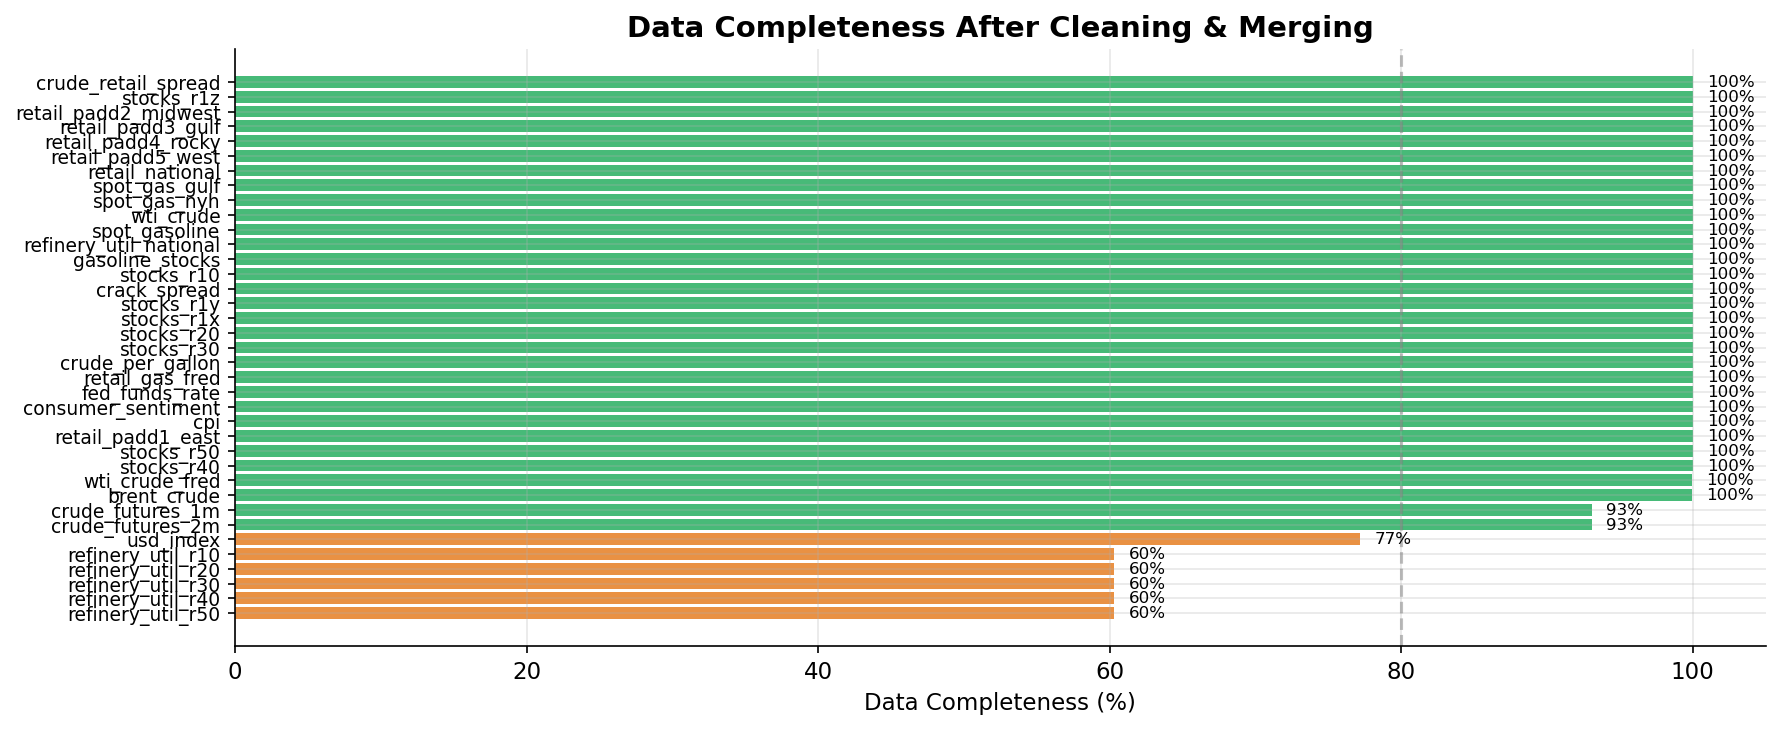

Saved: outputs/P1_data_completeness.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

# Data completeness by column (only key columns)
key_cols = [c for c in master.columns if not any(x in c for x in 
    ['_chg', '_pct', 'ma4', 'ma12', 'month', 'week_of', 'quarter', 'is_summer', 'target', 'direction'])]

completeness = master[key_cols].notna().mean().sort_values() * 100

colors = ['#27AE60' if v > 80 else '#E67E22' if v > 50 else '#E74C3C' for v in completeness.values]
ax.barh(range(len(completeness)), completeness.values, color=colors, alpha=0.85)
ax.set_yticks(range(len(completeness)))
ax.set_yticklabels(completeness.index, fontsize=9)
ax.set_xlabel('Data Completeness (%)')
ax.set_title('Data Completeness After Cleaning & Merging', fontsize=14, fontweight='bold')
ax.axvline(80, color='gray', linestyle='--', alpha=0.5)
ax.set_xlim(0, 105)

# Add percentage labels
for i, v in enumerate(completeness.values):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/P1_data_completeness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/P1_data_completeness.png')

## P2. Crude Oil vs Retail Gasoline — The Core Relationship

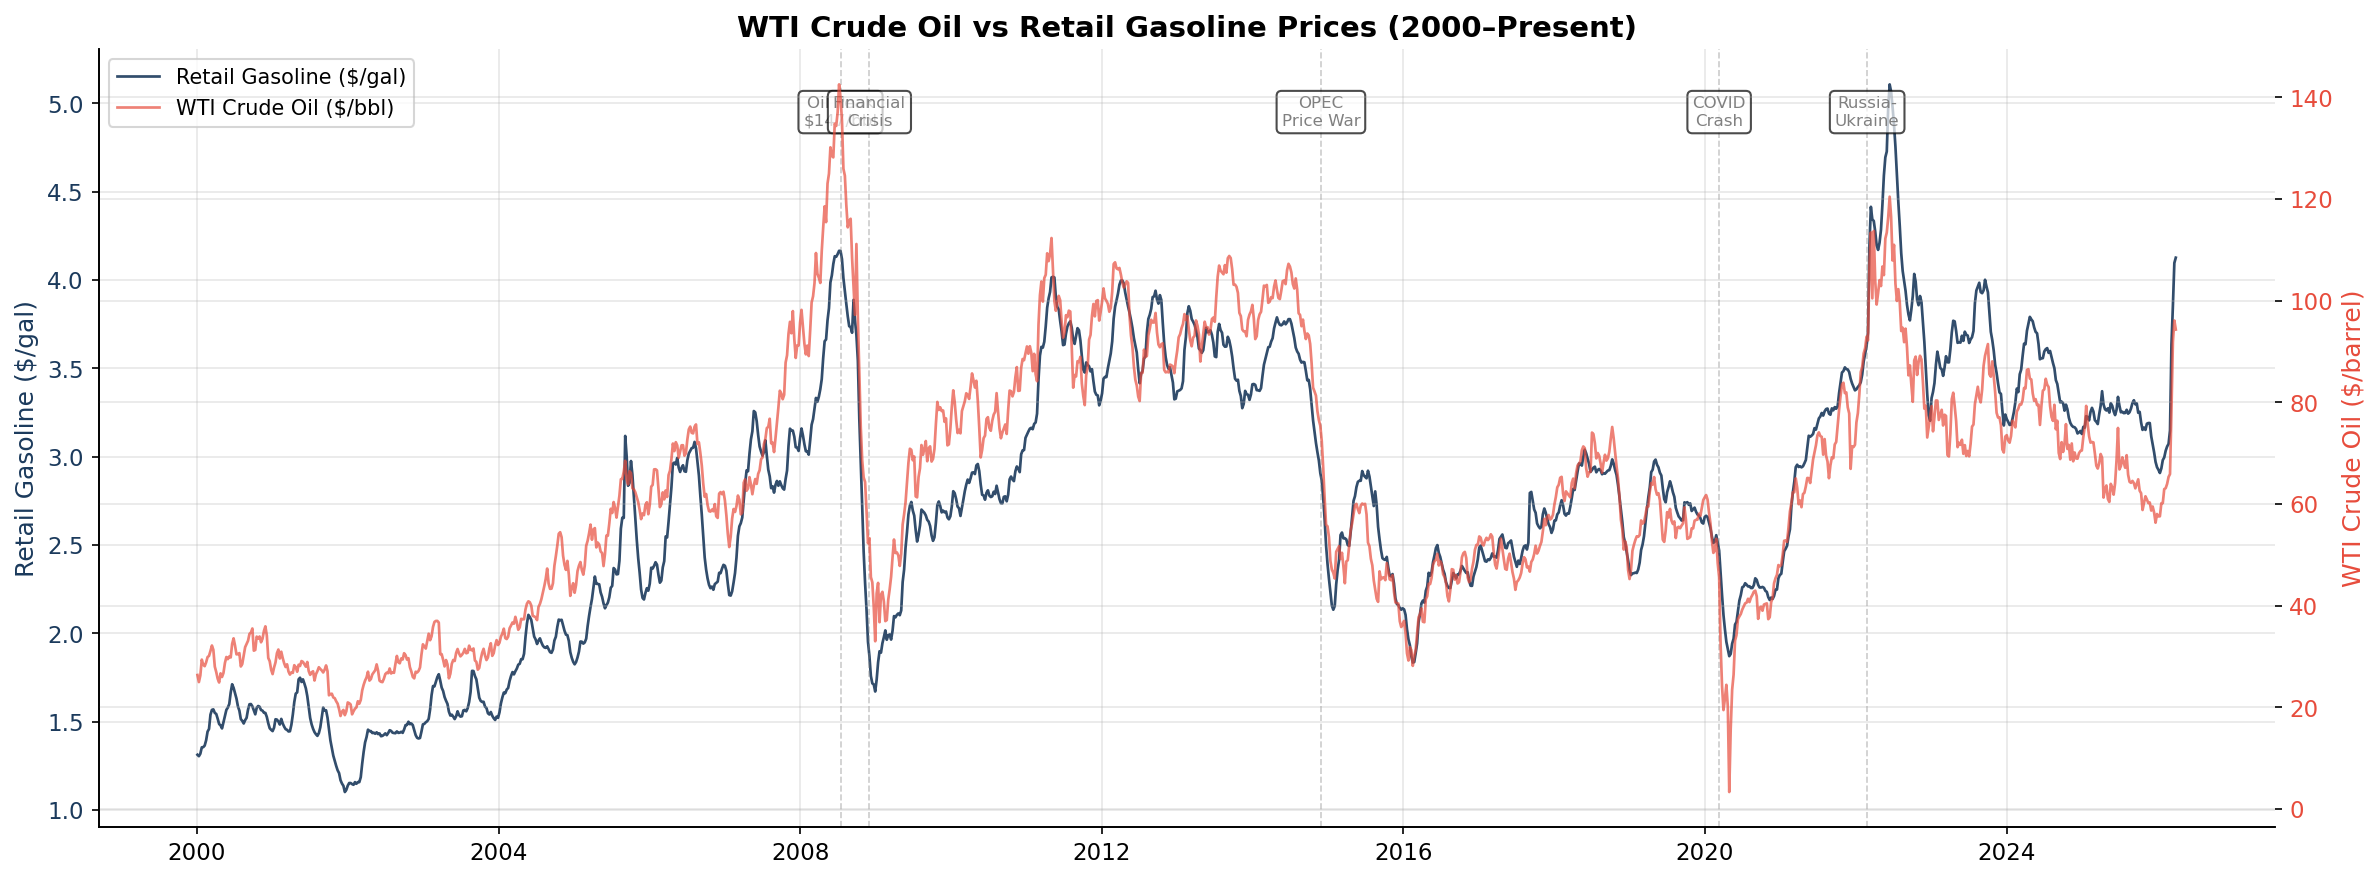

Saved: outputs/P2_crude_vs_retail.png


In [18]:
fig, ax1 = plt.subplots(figsize=(16, 6))

# Retail gas
if 'retail_national' in master.columns:
    ax1.plot(master.index, master['retail_national'], color='#1B3A5C', 
             linewidth=1.3, label='Retail Gasoline ($/gal)', alpha=0.9)
ax1.set_ylabel('Retail Gasoline ($/gal)', color='#1B3A5C', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1B3A5C')

# Crude oil on second axis
ax2 = ax1.twinx()
crude_col = 'wti_crude' if 'wti_crude' in master.columns else 'wti_crude_fred'
if crude_col in master.columns:
    ax2.plot(master.index, master[crude_col], color='#E74C3C', 
             linewidth=1.3, label='WTI Crude Oil ($/bbl)', alpha=0.7)
ax2.set_ylabel('WTI Crude Oil ($/barrel)', color='#E74C3C', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#E74C3C')

# Key events
events = [
    ('2008-07-14', 'Oil Peak\n$147/bbl'),
    ('2008-12-01', 'Financial\nCrisis'),
    ('2014-11-27', 'OPEC\nPrice War'),
    ('2020-03-09', 'COVID\nCrash'),
    ('2022-02-24', 'Russia-\nUkraine'),
]
for date_str, label in events:
    event_date = pd.Timestamp(date_str)
    if event_date >= master.index.min() and event_date <= master.index.max():
        ax1.axvline(event_date, color='gray', alpha=0.4, linestyle='--', linewidth=0.8)
        ax1.annotate(label, xy=(event_date, ax1.get_ylim()[1] * 0.95),
                     fontsize=8, ha='center', va='top', color='gray',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

ax1.set_title('WTI Crude Oil vs Retail Gasoline Prices (2000–Present)', 
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/P2_crude_vs_retail.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/P2_crude_vs_retail.png')

## P3. Regional Price Comparison (PADD Districts)

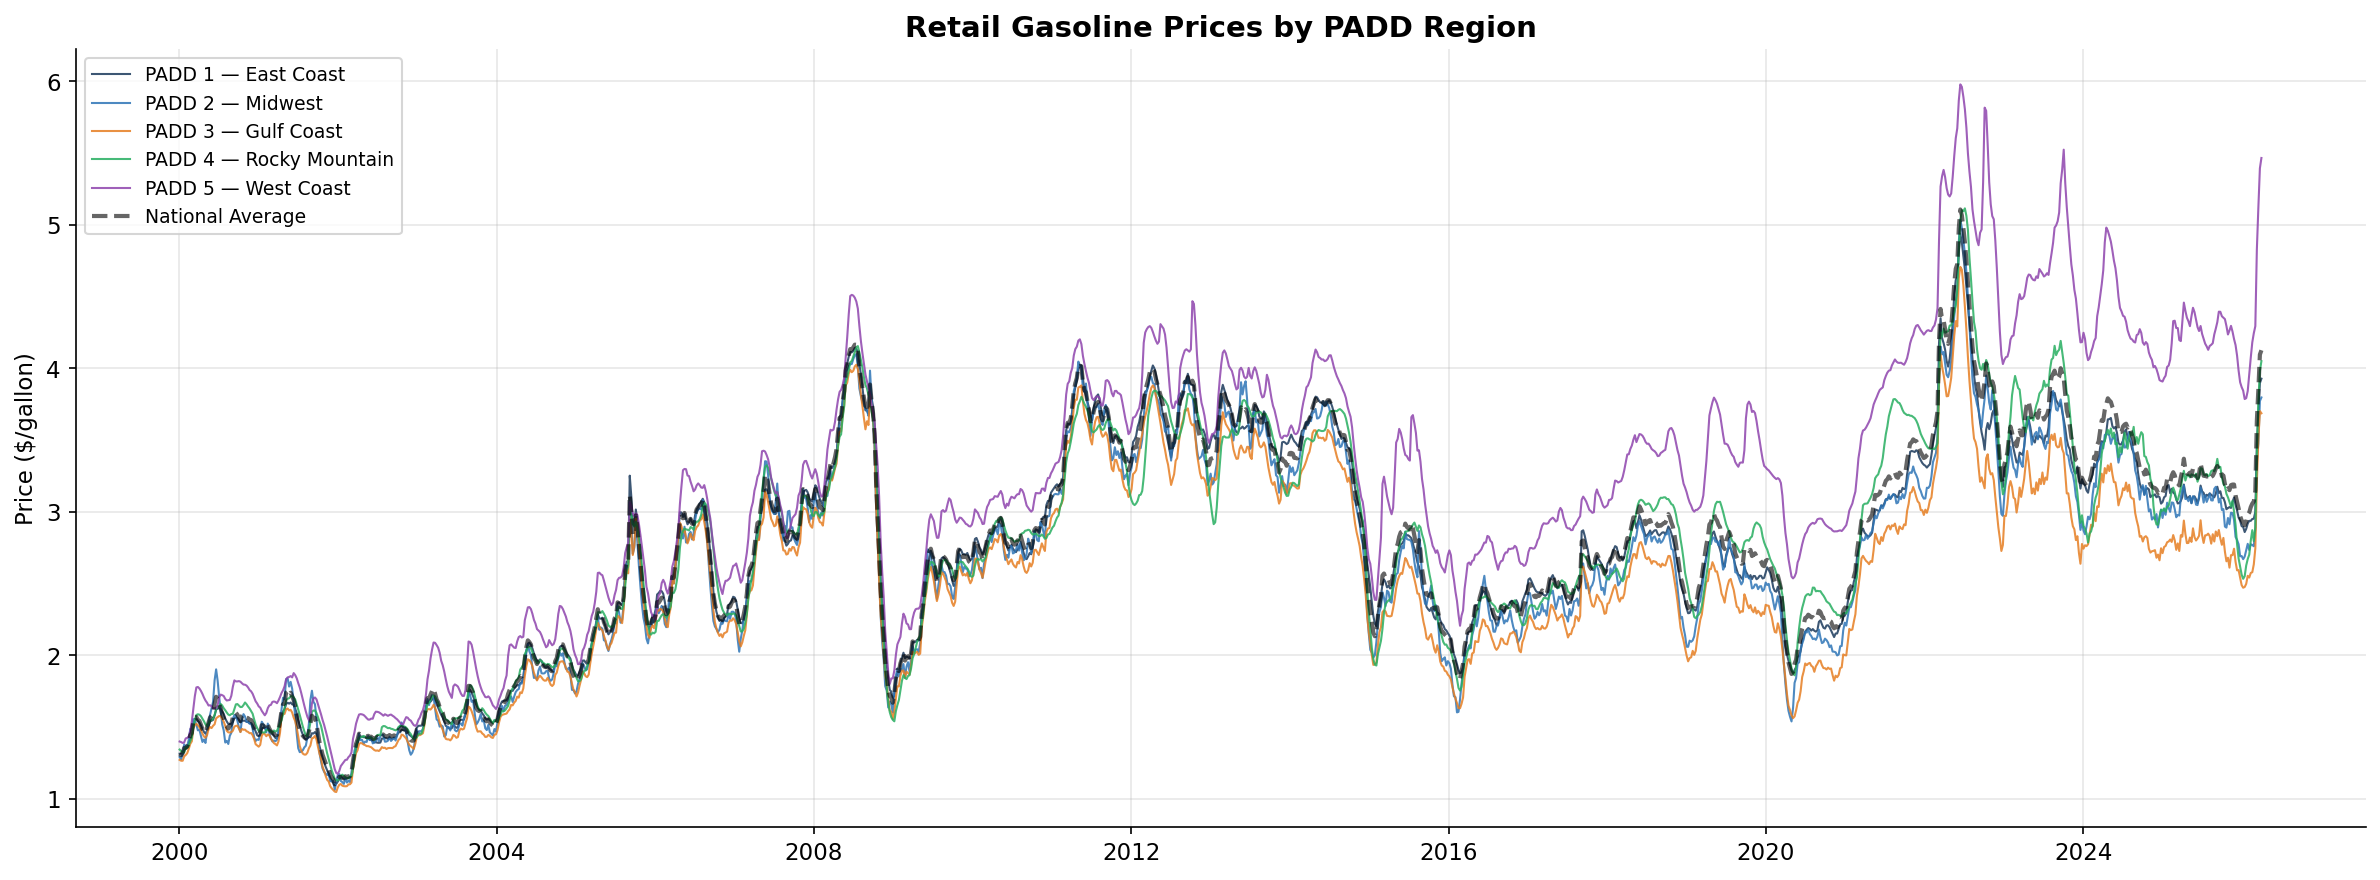

Saved: outputs/P3_padd_comparison.png


In [19]:
padd_cols = [c for c in master.columns if c.startswith('retail_padd')]

if padd_cols:
    fig, ax = plt.subplots(figsize=(16, 6))
    
    padd_labels = {
        'retail_padd1_east':    'PADD 1 — East Coast',
        'retail_padd2_midwest': 'PADD 2 — Midwest',
        'retail_padd3_gulf':    'PADD 3 — Gulf Coast',
        'retail_padd4_rocky':   'PADD 4 — Rocky Mountain',
        'retail_padd5_west':    'PADD 5 — West Coast',
    }
    colors = ['#1B3A5C', '#2E75B6', '#E67E22', '#27AE60', '#8E44AD']
    
    for i, col in enumerate(sorted(padd_cols)):
        label = padd_labels.get(col, col)
        ax.plot(master.index, master[col], color=colors[i % len(colors)],
                linewidth=1, label=label, alpha=0.85)
    
    if 'retail_national' in master.columns:
        ax.plot(master.index, master['retail_national'], color='black',
                linewidth=2, linestyle='--', label='National Average', alpha=0.6)
    
    ax.set_ylabel('Price ($/gallon)')
    ax.set_title('Retail Gasoline Prices by PADD Region', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('outputs/P3_padd_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/P3_padd_comparison.png')
else:
    print('No PADD columns found — check retail data cleaning step above')

## P4. Price Component Decomposition

Shows what makes up the price at the pump.

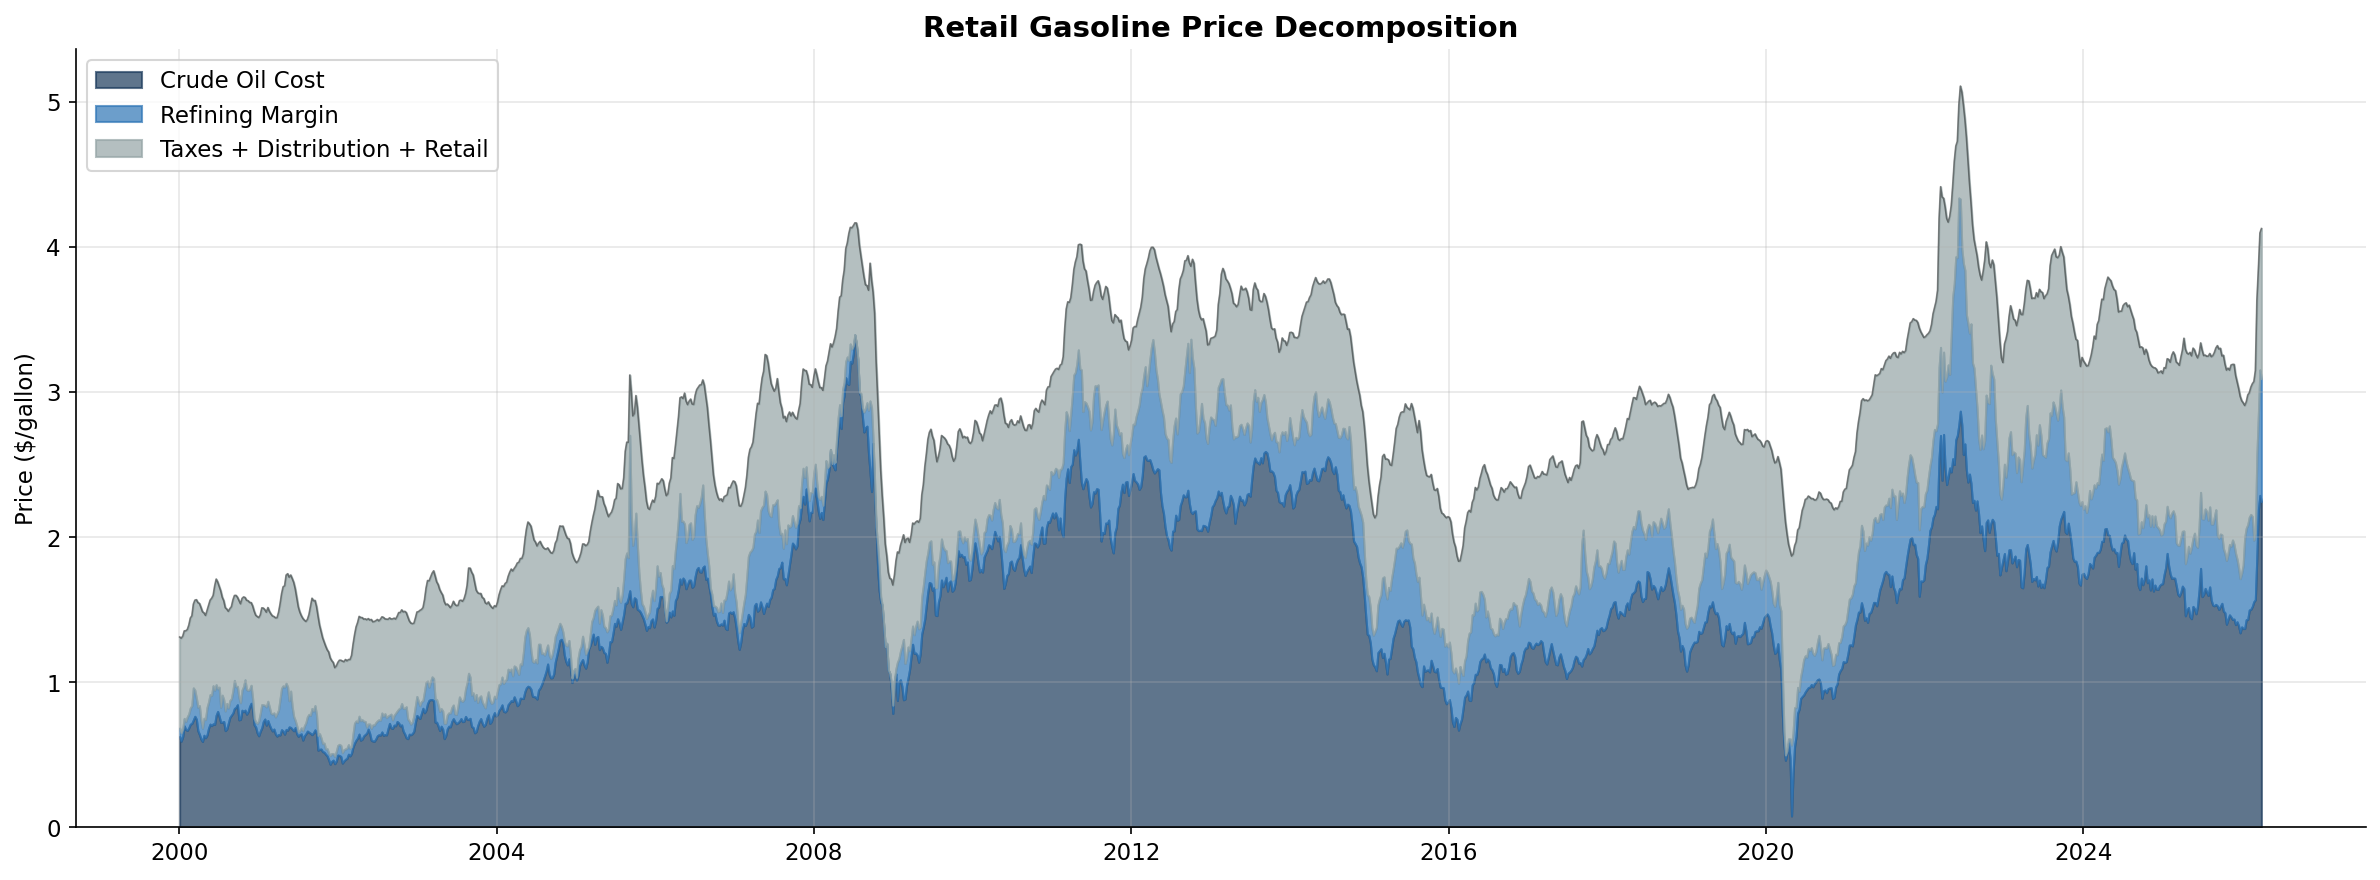

Saved: outputs/P4_price_decomposition.png


In [20]:
if 'crude_per_gallon' in master.columns and 'retail_national' in master.columns:
    fig, ax = plt.subplots(figsize=(16, 6))
    
    crude_gal = master['crude_per_gallon'].dropna()
    
    # Refining margin = spot gasoline - crude per gallon
    if 'crack_spread' in master.columns:
        refining = master['crack_spread'].clip(lower=0).reindex(crude_gal.index).fillna(0)
    else:
        refining = pd.Series(0, index=crude_gal.index)
    
    # Remaining = taxes + distribution + retail margin
    remaining = (master['retail_national'].reindex(crude_gal.index) - crude_gal - refining).clip(lower=0).fillna(0)
    
    ax.fill_between(crude_gal.index, 0, crude_gal, alpha=0.7, color='#1B3A5C', label='Crude Oil Cost')
    ax.fill_between(crude_gal.index, crude_gal, crude_gal + refining, alpha=0.7, color='#2E75B6', label='Refining Margin')
    ax.fill_between(crude_gal.index, crude_gal + refining, crude_gal + refining + remaining, 
                    alpha=0.7, color='#95A5A6', label='Taxes + Distribution + Retail')
    
    ax.plot(master.index, master['retail_national'], color='black', linewidth=0.8, alpha=0.4)
    
    ax.set_ylabel('Price ($/gallon)')
    ax.set_title('Retail Gasoline Price Decomposition', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left')
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.savefig('outputs/P4_price_decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/P4_price_decomposition.png')
else:
    print('Cannot create decomposition — missing crude or retail data')

## P5. Key Correlations

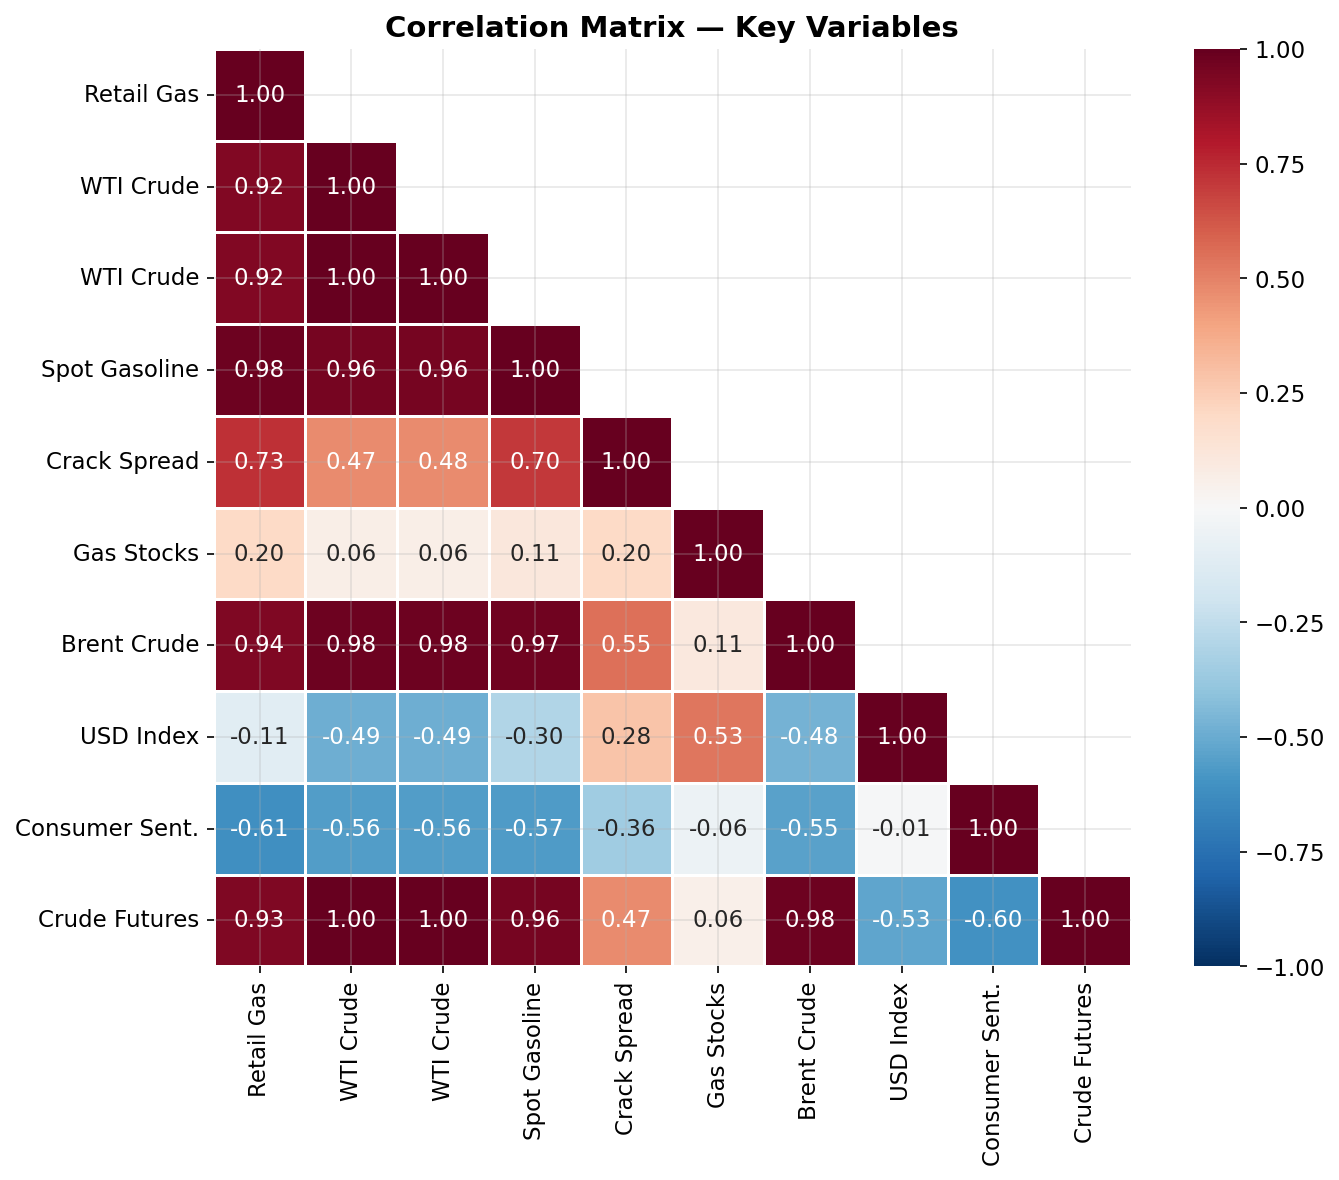

Saved: outputs/P5_correlations.png


In [21]:
import seaborn as sns

corr_cols = [c for c in [
    'retail_national', 'wti_crude', 'wti_crude_fred', 'spot_gasoline',
    'crack_spread', 'gasoline_stocks', 'brent_crude',
    'usd_index', 'consumer_sentiment', 'crude_futures_1m',
] if c in master.columns]

# Nice display names
display_names = {
    'retail_national': 'Retail Gas',
    'wti_crude': 'WTI Crude',
    'wti_crude_fred': 'WTI Crude',
    'spot_gasoline': 'Spot Gasoline',
    'crack_spread': 'Crack Spread',
    'gasoline_stocks': 'Gas Stocks',
    'brent_crude': 'Brent Crude',
    'usd_index': 'USD Index',
    'consumer_sentiment': 'Consumer Sent.',
    'crude_futures_1m': 'Crude Futures',
}

if len(corr_cols) >= 3:
    corr = master[corr_cols].corr()
    corr = corr.rename(index=display_names, columns=display_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
                square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title('Correlation Matrix — Key Variables', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('outputs/P5_correlations.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/P5_correlations.png')
else:
    print(f'Only {len(corr_cols)} columns available for correlation')

## P6. Supply Chain Dashboard (4-Panel Overview)

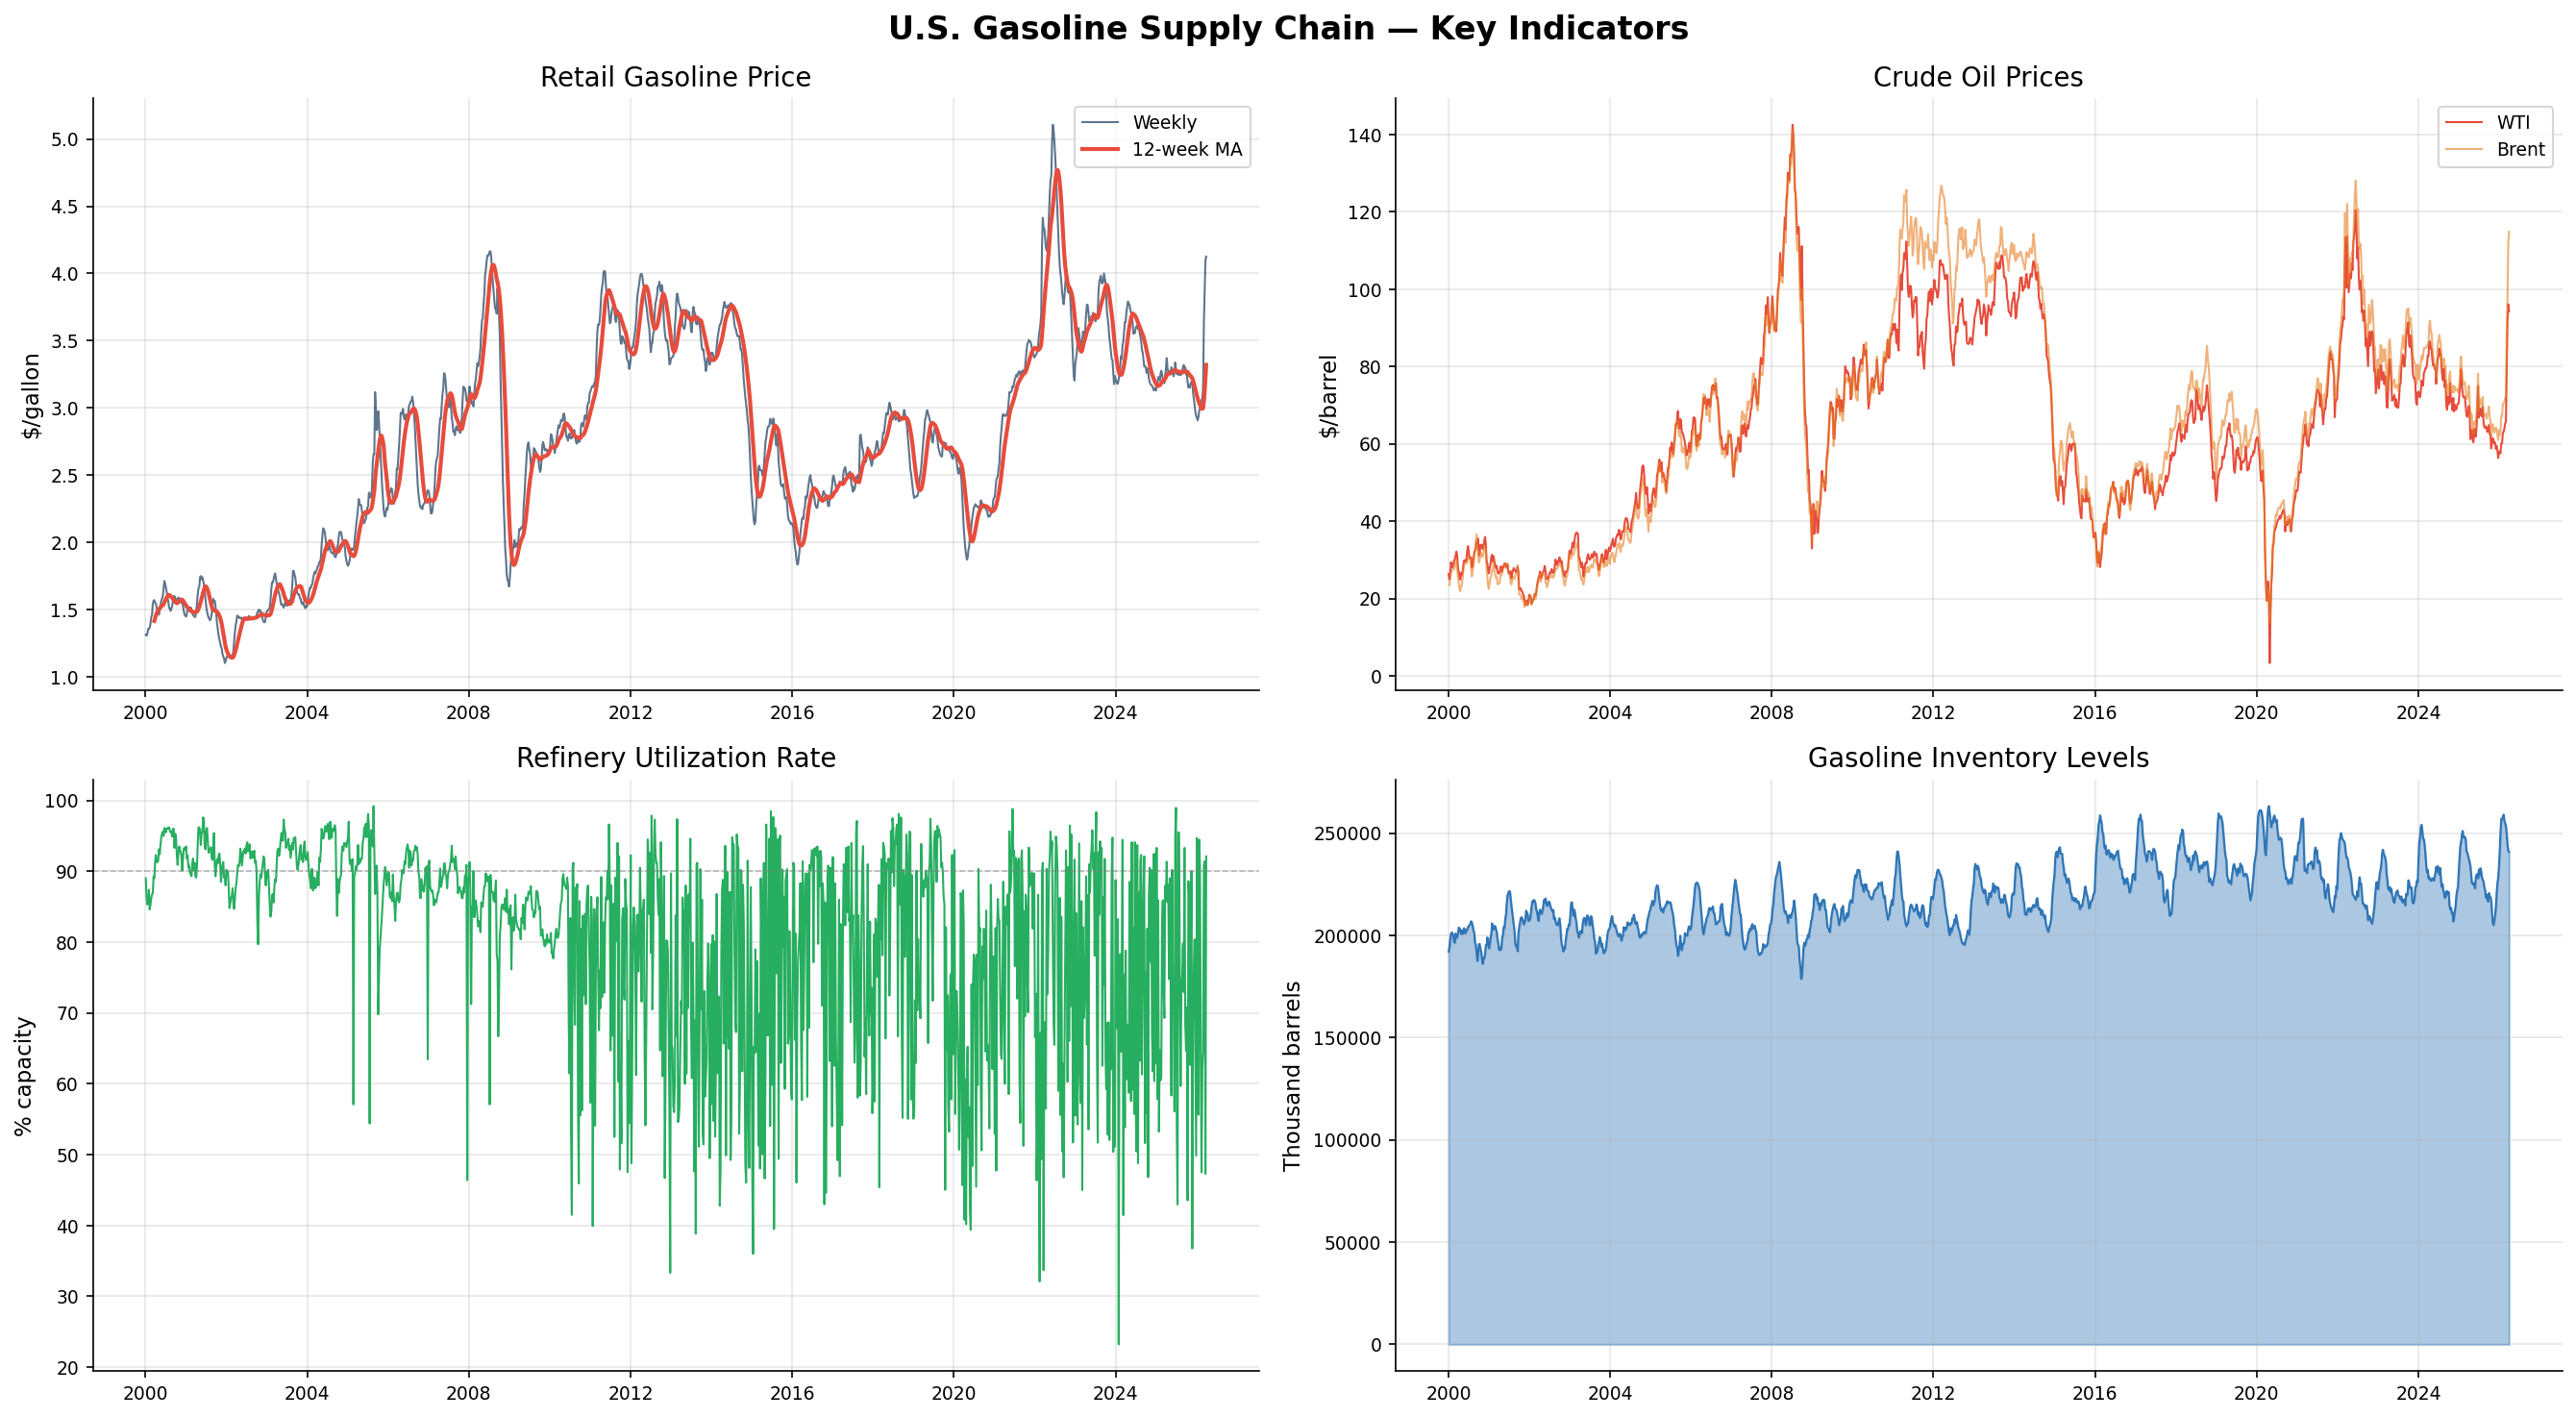

Saved: outputs/P6_supply_chain_dashboard.png


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('U.S. Gasoline Supply Chain — Key Indicators', fontsize=16, fontweight='bold')

# Panel 1: Retail gas price + moving averages
ax = axes[0, 0]
if 'retail_national' in master.columns:
    ax.plot(master.index, master['retail_national'], color='#1B3A5C', linewidth=1, alpha=0.7, label='Weekly')
if 'retail_ma12' in master.columns:
    ax.plot(master.index, master['retail_ma12'], color='#E74C3C', linewidth=2, label='12-week MA')
ax.set_title('Retail Gasoline Price')
ax.set_ylabel('$/gallon')
ax.legend(fontsize=9)

# Panel 2: Crude oil
ax = axes[0, 1]
crude_col = 'wti_crude' if 'wti_crude' in master.columns else 'wti_crude_fred'
if crude_col in master.columns:
    ax.plot(master.index, master[crude_col], color='#E74C3C', linewidth=1)
if 'brent_crude' in master.columns:
    ax.plot(master.index, master['brent_crude'], color='#E67E22', linewidth=1, alpha=0.6, label='Brent')
ax.set_title('Crude Oil Prices')
ax.set_ylabel('$/barrel')
ax.legend(['WTI', 'Brent'], fontsize=9)

# Panel 3: Refinery utilization
ax = axes[1, 0]
ref_col = [c for c in master.columns if 'refinery_util' in c and 'national' in c.lower()]
if not ref_col:
    ref_col = [c for c in master.columns if 'refinery_util' in c]
if ref_col:
    ax.plot(master.index, master[ref_col[0]], color='#27AE60', linewidth=1)
    ax.axhline(90, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax.set_title('Refinery Utilization Rate')
ax.set_ylabel('% capacity')

# Panel 4: Gasoline stocks
ax = axes[1, 1]
if 'gasoline_stocks' in master.columns:
    ax.fill_between(master.index, master['gasoline_stocks'], color='#2E75B6', alpha=0.4)
    ax.plot(master.index, master['gasoline_stocks'], color='#2E75B6', linewidth=1)
ax.set_title('Gasoline Inventory Levels')
ax.set_ylabel('Thousand barrels')

for ax in axes.flat:
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('outputs/P6_supply_chain_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/P6_supply_chain_dashboard.png')

## P7. Summary Statistics Table (for presentation slide)

In [23]:
summary_cols = [c for c in [
    'retail_national', 'wti_crude', 'wti_crude_fred', 'spot_gasoline',
    'crack_spread', 'crude_retail_spread', 'gasoline_stocks',
    'usd_index', 'consumer_sentiment',
] if c in master.columns]

summary = master[summary_cols].describe().round(3).T
summary['null_pct'] = (master[summary_cols].isna().mean() * 100).round(1)
summary = summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'null_pct']]
summary.columns = ['Count', 'Mean', 'Std Dev', 'Min', '25th', 'Median', '75th', 'Max', 'Null %']

print('KEY VARIABLE STATISTICS:')
print('=' * 100)
display(summary)

# Save for presentation
summary.to_csv('outputs/P7_summary_statistics.csv')
print('\nSaved: outputs/P7_summary_statistics.csv')

KEY VARIABLE STATISTICS:


,Count,Mean,Std Dev,Min,25th,Median,75th,Max,Null %
retail_national,1370.0,2.735,0.788,1.101,2.200,2.770,3.362,5.107,0.0
wti_crude,1370.0,63.783,24.890,3.320,44.992,63.060,81.655,142.520,0.0
wti_crude_fred,1369.0,63.821,24.882,8.252,44.928,63.132,81.572,142.872,0.1
spot_gasoline,1370.0,1.881,0.735,0.489,1.329,1.908,2.450,4.336,0.0
crack_spread,1370.0,0.362,0.236,-0.115,0.169,0.344,0.495,1.565,0.0
crude_retail_spread,1370.0,1.216,0.332,0.602,0.917,1.218,1.456,2.410,0.0
gasoline_stocks,1370.0,219391.207,15996.616,178739.000,207427.000,217516.500,229943.000,263234.000,0.0
usd_index,1057.0,106.212,12.312,85.755,93.681,109.875,116.495,129.378,22.8
consumer_sentiment,1370.0,81.648,14.042,50.000,70.975,82.700,93.000,112.000,0.0



Saved: outputs/P7_summary_statistics.csv


---
## Summary: What You've Done So Far

**For your Friday presentation, you can show:**

1. **Data Collection** — 5 EIA datasets + 7 FRED series, all pulled via public APIs
2. **Data Cleaning** — Handled nulls, filtered invalid values, aligned to weekly frequency
3. **Data Merging** — Combined 12 data sources into 1 master dataset
4. **Feature Engineering** — Calculated crack spread, price changes, rolling averages, seasonal flags
5. **Initial EDA** — Crude-vs-retail tracking, regional comparison, price decomposition, correlation matrix, supply chain dashboard

**Charts saved in the `outputs/` folder:**
- P1: Data completeness
- P2: Crude vs retail over time (with event annotations)
- P3: Regional PADD comparison
- P4: Price decomposition
- P5: Correlation matrix
- P6: Supply chain dashboard
- P7: Summary statistics table

In [24]:
# Final check: list all saved files
print('📁 All output files:')
for f in sorted(Path('outputs').glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f'   {f.name:<40} {size_kb:.0f} KB')

print(f'\n📁 Processed data:')
for f in sorted(Path('data/processed').glob('*')):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f'   {f.name:<40} {size_mb:.1f} MB')

print(f'\n✅ All done! Ready for your Friday presentation.')

📁 All output files:
   P1_data_completeness.png                 172 KB
   P2_crude_vs_retail.png                   280 KB
   P3_padd_comparison.png                   413 KB
   P4_price_decomposition.png               314 KB
   P5_correlations.png                      150 KB
   P6_supply_chain_dashboard.png            485 KB
   P7_summary_statistics.csv                1 KB

📁 Processed data:
   master_dataset.csv                       0.7 MB

✅ All done! Ready for your Friday presentation.
